<a href="https://colab.research.google.com/github/Shivieo/Deep-Learning-Framework-Assignment/blob/main/Deep_Learning_Frameworks_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DEEP LEARNING FRAMEWORKS

In [1]:
#1. What is TensorFlow 2.0, and how is it different from TensorFlow 1.x?
# TensorFlow 2.0 is the next major version of Google's open-source machine learning framework. It provides a comprehensive ecosystem of tools for developers, researchers, and organizations to build and deploy machine learning models. The core of TensorFlow is its ability to perform numerical computations using tensors (multi-dimensional arrays) and data flow graphs. TensorFlow 2.0 aims to make this powerful framework more accessible and intuitive.
# Differences:
# Eager Execution by Default: This is perhaps the most significant change. In TensorFlow 1.x, you first defined a computational graph and then executed it in a separate session. TensorFlow 2.0 executes operations immediately as you write them, making it feel more like standard Python. This simplifies debugging and makes the framework more intuitive for beginners.
# Simplified and Integrated API with Keras: TensorFlow 2.0 has adopted Keras as its high-level API (tf.keras). This provides a user-friendly and consistent way to build neural networks. Many redundant modules and functionalities from tf.contrib have been removed or integrated into the core API, leading to a cleaner and more focused framework.
# tf.function for Graph Optimization: While eager execution is the default, TensorFlow 2.0 still leverages the power of graph execution for performance and deployment. You can use the @tf.function decorator to mark Python functions for just-in-time (JIT) compilation into TensorFlow graphs. This allows for optimizations and deployment on various platforms.
# Improved Data Handling with tf.data: The tf.data.Dataset API provides a more efficient and flexible way to build input pipelines for your models, replacing the older queue-based approaches.
# More Pythonic Control Flow: Within functions decorated with @tf.function, you can use standard Python control flow statements (like if, for, while), which TensorFlow automatically translates into graph control flow.
# No More Global Variables: TensorFlow 2.0 encourages a more object-oriented approach where variables are typically managed within layers or models, reducing the reliance on global collections.

In [2]:
#2. How do you install TensorFlow 2.0?
# pip install tensorflow-gpu
import tensorflow as tf
print(tf.__version__)

2.18.0


In [3]:
#3. What is the primary function of the tf.function in TensorFlow 2.0?
# The primary function of tf.function in TensorFlow 2.0 is to transform Python functions into TensorFlow graphs for optimized execution and deployment.

In [4]:
#4. What is the purpose of the Model class in TensorFlow 2.0?
# The primary purpose of the Model class in TensorFlow 2.0, specifically the tf.keras.Model class, is to define and manage the architecture and behavior of your machine learning models. It serves as a fundamental building block for creating neural networks and other trainable models within the Keras API, which is the central high-level API in TensorFlow 2.0.

In [5]:
#5. How do you create a neural network in TensorFlow 2.0?
import tensorflow as tf

# Define your model as a sequence of layers
model_sequential = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(100,)), # Input layer with 100 features
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax') # Output layer for 10 classes
])

# Compile your model
model_sequential.compile(optimizer='adam',
                        loss='categorical_crossentropy',
                        metrics=['accuracy'])

# Get a summary of the model's architecture
model_sequential.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,874 (34.66 KB)

 Trainable params: 8,874 (34.66 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#6. What is the importance of Tensor Space in TensorFlow?
# TensorFlow doesn't have a formal, explicitly named "Tensor Space" object or class in the same way it has tf.Tensor or tf.Variable, the idea of the space in which tensors reside is absolutely fundamental to how TensorFlow operates and why it's so powerful for numerical computation and machine learning.
# The concept of "Tensor Space" in TensorFlow is the underlying framework that allows the library to:

# Structure and organize data.
# Apply consistent and efficient mathematical operations.
# Represent complex datasets and model parameters.
# Compute gradients for learning.
# Optimize computations for diverse hardware.

In [6]:
#7. How can TensorBoard be integrated with TensorFlow 2.0?
# The primary way to integrate TensorBoard with TensorFlow 2.0 is through TensorBoard callbacks during the training process. These callbacks automatically log relevant information that TensorBoard can then read and display.

# Here's a step-by-step guide:

# Import the TensorBoard Callback:


import tensorflow as tf
import datetime

# For loading other datasets if needed
# (e.g., MNIST for a simple example)
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)

# Define your model (using Sequential API for simplicity)
model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

# Compile your model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
# Define the TensorBoard Callback:
# You need to create an instance of the tf.keras.callbacks.TensorBoard callback. You'll typically specify a log_dir where TensorFlow will save the data that TensorBoard will read. It's good practice to organize your logs by timestamp to keep track of different runs.


log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)
# log_dir: The path to the directory where TensorBoard will store the log files. Organizing by date and time helps in managing different training runs.
# histogram_freq=1: This tells TensorBoard to log histograms of the weights and biases of your layers every epoch. You can set this to 0 to disable histogram logging or a higher number to log less frequently.
# Integrate the Callback During Training:
#     When you train your model using the model.fit() method, you pass the tensorboard_callback to the callbacks argument.

model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test), callbacks=[tensorboard_callback])
# TensorFlow will now automatically log data (like loss, metrics, histograms, etc.) to the specified log_dir during each epoch of training and validation.

# Launch TensorBoard:
# After (or even during) training, you can launch TensorBoard from your terminal or command prompt. Make sure you have activated your TensorFlow environment. Navigate to the root directory of your project (or the directory containing the logs folder) and run:

# tensorboard --logdir logs/fit
# TensorBoard will then provide a URL (usually http://localhost:6006/) that you can open in your web browser to view the visualizations.

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8737 - loss: 0.4370 - val_accuracy: 0.9603 - val_loss: 0.1332
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9643 - loss: 0.1194 - val_accuracy: 0.9701 - val_loss: 0.1023
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9758 - loss: 0.0794 - val_accuracy: 0.9757 - val_loss: 0.0803
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9828 - loss: 0.0582 - val_accuracy: 0.9731 - val_loss: 0.0867
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9869 - loss: 0.0423 - val_accuracy: 0.9746 - val_loss: 0.0808


In [7]:
#8. What is the purpose of TensorFlow Playground?
# The primary purpose of the TensorFlow Playground is to serve as an educational and interactive web application for visualizing the training process of simple neural networks in real-time.
# Think of it as a sandbox environment where you can experiment with different neural network architectures, hyperparameters, and datasets, and immediately see how these choices affect the learning process.

In [8]:
#9. What is Netron, and how is it useful for deep learning models?
# Netron is an open-source, cross-platform viewer for neural network, deep learning, and machine learning models. Developed by Lutz Roeder, it provides a user-friendly graphical interface to visualize the architecture of various model formats.

# How Netron is Useful for Deep Learning Models:

# Model Understanding and Exploration:

# Visualizing Complex Architectures: Deep learning models can become incredibly intricate with numerous layers and connections. Netron provides a clear, visual representation of the model's structure, making it easier to understand the flow of data and the relationships between different layers.
# Inspecting Layer Details: By clicking on individual layers in the Netron interface, you can inspect their properties, such as layer type (e.g., Convolutional, Dense, Recurrent), input and output shapes, activation functions, kernel sizes, and the number of parameters. This detailed view helps in debugging and understanding the role of each component.
# Identifying Potential Issues: Visualizing the model can help identify architectural errors or unexpected connections. For instance, you might spot a layer with an incorrect input shape or an unintended skip connection.
# Debugging and Troubleshooting:

# Tracing Data Flow: Netron allows you to trace the flow of data through the network, which can be crucial when debugging issues with data dimensionality or layer compatibility.
# Verifying Model Conversion: When converting models between different frameworks (e.g., TensorFlow to ONNX), Netron can be used to verify that the converted model accurately reflects the original architecture.
# Collaboration and Communication:

# Sharing Model Architecture: The visual representations generated by Netron can be easily shared with collaborators, making it simpler to discuss and explain model designs without requiring everyone to parse through code.
# Documentation: Netron visualizations can be included in research papers, documentation, and presentations to clearly illustrate the model architecture.
# Multi-Framework Support:

# Netron supports a wide range of deep learning frameworks and model formats, including:
# TensorFlow (.pb, .ckpt, .h5, .keras, .tflite)
# PyTorch (.pt, .pth, .onnx, .torchscript)
# ONNX (.onnx)
# Keras (.h5, .keras)
# TensorFlow Lite (.tflite)
# Core ML (.mlmodel)
# Caffe (.caffemodel)
# MXNet (.model, -symbol.json)
# And many more (experimental support for others).
# This broad compatibility makes it a versatile tool for anyone working with different frameworks.
# Ease of Use and Accessibility:

# Netron has a simple and intuitive user interface. You can open model files directly through the application or even use a browser-based version without installation.
# It is lightweight and doesn't require complex dependencies, making it easy to get started.

In [9]:
#10. What is the difference between TensorFlow and PyTorch?
# The key distinctions between TensorFlow and PyTorch:

# 1. Computational Graph Definition:

# TensorFlow: Historically (in 1.x), TensorFlow used a static computational graph. You first defined the entire model architecture symbolically, and then you would compile and run this graph in a separate session. TensorFlow 2.0 introduced eager execution by default, which makes it more dynamic and imperative, similar to PyTorch. However, TensorFlow still retains the ability to define and use static graphs (using tf.function) for optimization and deployment.
# PyTorch: PyTorch utilizes a dynamic computational graph (define-by-run). The graph is built on the fly as the operations are executed. This allows for more flexibility and easier debugging, as you can inspect intermediate values and change the graph structure during runtime.
# 2. Ease of Use and Pythonic Nature:

# PyTorch: Generally considered more Pythonic and intuitive, especially for researchers and those new to deep learning. Its dynamic nature aligns well with standard Python debugging tools and workflows. The syntax often feels more natural for Python developers.
# TensorFlow: While TensorFlow 1.x had a steeper learning curve due to its static graph approach, TensorFlow 2.0 significantly improved its usability with eager execution and tighter integration with Keras, its high-level API. However, some users still find PyTorch slightly more straightforward for experimentation and rapid prototyping.
# 3. Debugging:

# PyTorch: Debugging is generally easier due to its dynamic graph. You can use standard Python debugging tools (like pdb) to step through your code and inspect tensors at any point during execution.
# TensorFlow: Debugging static graphs in TensorFlow 1.x could be challenging. Eager execution in TensorFlow 2.0 has made debugging much more intuitive, bringing it closer to the ease of debugging in PyTorch.
# 4. Model Building:

# PyTorch: Encourages a more direct, object-oriented approach to model building using classes and the torch.nn module. Defining custom layers and models often involves writing more explicit Python code.
# TensorFlow: Offers multiple levels of abstraction through Keras (Sequential API for linear stacks, Functional API for complex graphs, and Model Subclassing for full customization). This provides flexibility for different levels of users and model complexity.
# 5. Deployment and Production:

# TensorFlow: Has historically been stronger in production deployment due to TensorFlow Serving, TensorFlow Lite, and TensorFlow.js, which provide mature ecosystems for deploying models on servers, mobile devices, and web browsers, respectively.
# PyTorch: Has made significant strides in production deployment with TorchServe and improved ONNX (Open Neural Network Exchange) support, making it increasingly viable for production environments. However, TensorFlow's ecosystem for deployment is still generally considered more comprehensive and mature.
# 6. Performance and Speed:

# Both frameworks are highly optimized and can leverage GPUs and TPUs for accelerated computation.
# TensorFlow's static graphs (when used) can sometimes allow for more aggressive graph-level optimizations, potentially leading to faster execution in certain scenarios, especially for large-scale deployments.
# PyTorch's dynamic nature can sometimes have a slight overhead in terms of raw execution speed compared to a highly optimized static graph. However, the difference often becomes negligible, especially with recent optimizations in both frameworks.
# 7. Community and Ecosystem:

# TensorFlow: Backed by Google, it has a large and mature community with extensive documentation, tutorials, and a wide range of tools and libraries (e.g., TensorBoard, TFX).
# PyTorch: Has a rapidly growing and very active community, particularly strong in the research domain. Its ecosystem is also expanding quickly, with excellent libraries like Hugging Face Transformers.
# 8. Research vs. Production Focus:

# PyTorch: Initially gained popularity in the research community due to its flexibility, ease of use, and dynamic nature, which are well-suited for experimentation.
# TensorFlow: Was initially adopted more widely in industry and production due to its scalability and deployment capabilities. However, with the advancements in both frameworks, this distinction is becoming less rigid. PyTorch is increasingly used in production, and TensorFlow is becoming more researcher-friendly.

In [10]:
#11. How do you install Pytorch?
# CPU only (pip)
# pip install torch torchvision torchaudio
# cuda 11.8 (pip):
# pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
import torch
print(torch.__version__)
print(torch.cuda.is_available())

2.6.0+cu124
False


In [11]:
#12. What is the basic structure of a PyTorch neural network?
import torch
import torch.nn as nn
import torch.nn.functional as F

class YourNeuralNetwork(nn.Module):
    def __init__(self):
        super(YourNeuralNetwork, self).__init__()
        # Define the layers of your network here

        # Example layers:
        self.linear1 = nn.Linear(in_features=10, out_features=20)
        self.linear2 = nn.Linear(in_features=20, out_features=5)
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.flatten = nn.Flatten()
        self.dropout = nn.Dropout(p=0.5)

    def forward(self, x):
        # Define the forward pass of your network here
        # This specifies how the input data flows through the layers

        # Example forward pass for a simple network:
        x = self.relu(self.linear1(x))
        x = self.linear2(x)
        return x

        # Example forward pass for a convolutional network:
        # x = self.relu(self.conv1(x))
        # x = self.maxpool(x)
        # x = self.relu(self.conv2(x))
        # x = self.maxpool(x)
        # x = self.flatten(x)
        # x = self.relu(self.linear1(x))
        # x = self.dropout(x)
        # x = self.linear2(x)
        # return x

if __name__ == '__main__':
    # Instantiate your neural network
    model = YourNeuralNetwork()
    print(model)

    # Create a dummy input tensor
    input_tensor = torch.randn(1, 10) # Batch size 1, 10 input features

    # Pass the input through the network
    output_tensor = model(input_tensor)
    print(output_tensor.shape)

YourNeuralNetwork(
  (linear1): Linear(in_features=10, out_features=20, bias=True)
  (linear2): Linear(in_features=20, out_features=5, bias=True)
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
  (maxpool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (dropout): Dropout(p=0.5, inplace=False)
)
torch.Size([1, 5])


In [12]:
#13. What is the significance of tensors in PyTorch?
# The significance of tensors in Pytorch
# 1. Fundamental Data Structure:

# Everything in PyTorch is a Tensor: Whether you're dealing with input data, model parameters (weights and biases), intermediate computations, or the final output, it's all represented as tensors. They are the basic unit of data in PyTorch.
# Homogeneous Data Type: Elements within a single tensor must have the same data type (e.g., float32, int64). This allows for efficient storage and computation.
# 2. Numerical Computation Powerhouse:

# Efficient Operations: PyTorch provides a vast library of highly optimized functions for performing mathematical operations on tensors, including arithmetic, linear algebra, Fourier transforms, and more. These operations are often implemented in highly optimized C++ and can be significantly faster than standard Python loops, especially for large datasets.
# GPU Acceleration: One of PyTorch's key strengths is its seamless integration with GPUs (Graphics Processing Units). Tensors can be easily moved to and from the GPU, allowing for massive parallel computations that dramatically speed up training and inference for deep learning models. This is crucial for handling the large datasets and complex models common in modern AI.
# 3. Automatic Differentiation (Autograd):

# Tracking Computations: PyTorch's automatic differentiation engine, torch.autograd, works by remembering the sequence of operations performed on tensors. When you set requires_grad=True for a tensor, PyTorch starts tracking all subsequent operations on it.
# Gradient Calculation: This tracking allows PyTorch to automatically compute gradients (derivatives) of any tensor with respect to any other tensor that contributed to its computation. This is the backbone of training neural networks using backpropagation. Without tensors that can track gradients, training complex models would be incredibly difficult and inefficient.
# 4. Representing Complex Data:

# Multi-Dimensionality for Rich Information: The multi-dimensional nature of tensors makes them ideal for representing complex data:
# Images: Can be represented as 3D tensors (height, width, color channels) or 4D tensors (batch size, height, width, color channels).
# Text: Can be represented as sequences of word embeddings (2D tensors) or batched sequences (3D tensors).
# Time Series: Can be represented as 2D tensors (time steps, features) or 3D tensors (batch size, time steps, features).
# Volumetric Data: Can be represented as 4D or 5D tensors.
# 5. Foundation for Neural Networks:

# Model Parameters: The weights and biases of neural network layers are stored as tensors. During training, these tensors are updated based on the calculated gradients.
# Layer Inputs and Outputs: The data flowing through the layers of a neural network at each step is represented as tensors.
# Loss Functions and Metrics: The output of loss functions and various evaluation metrics are also tensors.
# 6. Interoperability:

# NumPy Bridge: PyTorch tensors can be easily converted to and from NumPy arrays, allowing for seamless integration with the vast ecosystem of scientific computing tools in Python. However, PyTorch tensors offer the crucial advantage of GPU acceleration and automatic differentiation.

In [13]:
#14. What is the difference between torch.Tensor and torch.cuda.Tensor in PyTorch?
# torch.Tensor (CPU Tensor):

# When you create a tensor using the basic torch.Tensor constructor or factory functions like torch.zeros(), torch.ones(), torch.randn(), etc., by default, the tensor's data is allocated in the CPU's main memory (RAM).
# All the mathematical operations performed on these torch.Tensor instances are executed by the CPU.
# These tensors are suitable for general-purpose numerical computation on the CPU.
# They are the standard tensor type when you don't explicitly specify a device or when a CUDA-enabled GPU isn't available or isn't being used.
# torch.cuda.Tensor (GPU Tensor):

# torch.cuda.Tensor represents a tensor whose data is allocated in the memory of an NVIDIA CUDA-enabled GPU.1

# Operations performed on torch.cuda.Tensor instances are executed by the GPU, which is highly parallelized and can significantly accelerate many tensor computations, especially those involved in deep learning (like matrix multiplications, convolutions, etc.).
# To create a torch.cuda.Tensor, you typically need to:
# Have an NVIDIA GPU with the necessary CUDA drivers installed.
# Explicitly move an existing torch.Tensor to the GPU using the .cuda() method or by specifying the device argument in tensor creation functions.

In [14]:
#15. What is the purpose of the torch.optim module in PyTorch?
# The torch.optim module provides the tools to minimize the loss function of your model. The loss function quantifies the error between your model's predictions and the actual ground truth. The optimization algorithm uses the gradients of the loss with respect to the model's parameters to iteratively adjust these parameters in a direction that reduces the loss.

In [15]:
#16. What are some common activation functions used in neural networks?
# Here are some common activation functions used in neural networks:

# 1. Sigmoid (Logistic):
# Output Range: (0, 1)
# Characteristics:
# Squashes the input to a probability-like range, making it useful for binary classification output layers.
# Historically popular but has largely been replaced in hidden layers due to the vanishing gradient problem (gradients become very small in the saturated regions, hindering learning) and its output not being zero-centered.

# 2. Tanh (Hyperbolic Tangent):
# Output Range: (-1, 1)
# Characteristics:
# Similar to sigmoid but its output is zero-centered, which can sometimes lead to faster convergence.
# Still suffers from the vanishing gradient problem, though less severely than sigmoid due to the wider non-saturated region.

# 3. ReLU (Rectified Linear Unit):
# Formula: f(x)=max(0,x)
# Output Range: [0,∞)
# Characteristics:
# Simple and computationally efficient.
# Alleviates the vanishing gradient problem for positive inputs.
# Can suffer from the "dying ReLU" problem where neurons can become inactive if their input is consistently negative, as the gradient becomes zero.

# 4. Leaky ReLU:
# if x≥0
# if x<0
# ​
#   (where α is a small positive constant, e.g., 0.01)
# Output Range: (−∞,∞)
# Characteristics:
# Addresses the "dying ReLU" problem by allowing a small, non-zero gradient when the input is negative.
# The small slope for negative inputs helps information flow even when the neuron is not actively firing in the positive region.

# 5. Parametric ReLU (PReLU):
# Formula: Similar to Leaky ReLU, but α is a learnable parameter that is optimized during training.
# Output Range: (−∞,∞)
# Characteristics:
# Allows the network to adapt the slope of the negative part of the function.
# Can potentially provide better performance but adds a small number of extra parameters to learn.

# 6. Softmax:
# Output Range: (0, 1) for each output, with the sum of all outputs equaling 1.
# Characteristics:
# Typically used in the output layer for multi-class classification.
# Converts a vector of raw scores (logits) into a probability distribution over the classes.

# 7. Softplus:
# Output Range: (0,∞)
# Characteristics:
# A smooth approximation of the ReLU function.
# Less prone to the "dying neuron" problem than ReLU.
# Computationally more expensive than ReLU.

# 8. ELU (Exponential Linear Unit):
# Output Range: (−α,∞)
# Characteristics:
# Similar to Leaky ReLU in addressing the "dying ReLU" problem.
# Can produce negative outputs, which can push the mean activation closer to zero, potentially speeding up learning.
# The exponential part can be slightly more computationally expensive.

In [16]:
#17. What is the difference between torch.nn.Module and torch.nn.Sequential in PyTorch?
# The difference between torch.nn.Module and torch.nn.Sequential:

# torch.nn.Module:

# The Base Class: torch.nn.Module is the base class for all neural network modules in PyTorch. This includes individual layers (like nn.Linear, nn.Conv2d, nn.ReLU), loss functions (like nn.CrossEntropyLoss, nn.MSELoss), and even entire neural networks themselves.
# Flexibility and Customization: When you create your own neural network architecture, you will almost always subclass nn.Module. This gives you complete control over the structure and the forward pass of your model.
# Defining Layers in __init__: Inside the __init__ method of your custom nn.Module subclass, you define the individual layers that your network will use as instance attributes (e.g., self.linear1 = nn.Linear(...)).
# Implementing the Forward Pass in forward: You must implement the forward(self, x) method within your nn.Module subclass. This method defines how the input tensor x flows through the layers you defined in __init__ to produce the output. You have complete freedom here to define complex data flows, branching, looping, etc.
# Managing Parameters: nn.Module automatically keeps track of all the trainable parameters (weights and biases) of the layers you define within it. You can access these parameters using model.parameters().
# Think of nn.Module as the general blueprint for any component of a neural network, from a single brick (layer) to an entire building (complex model). You have the freedom to design the building as you see fit.

# torch.nn.Sequential:

# A Container for Sequential Modules: torch.nn.Sequential is a container that allows you to stack a sequence of nn.Module instances in a linear order. It's designed for building simple neural networks where the data flows directly from one layer to the next without any branching or complex connections.
# Simplified Forward Pass: When you pass an input tensor to a nn.Sequential instance, it automatically passes the output of each module in the sequence as the input to the next module. You don't need to explicitly define a forward method in this case; nn.Sequential handles it for you.
# Convenience for Linear Stacks: It provides a concise way to define and execute a straightforward sequence of layers.

In [17]:
#18. How can you monitor training progress in TensorFlow 2.0?
# Monitoring training progress in TensorFlow 2.0 is crucial to understanding how well your model is learning here in Varanasi! Just like keeping an eye on the rising and setting of the sun over the Ganges, tracking your training helps you identify potential issues and optimize your process.

In [18]:
#19. How does the Keras API fit into TensorFlow 2.0?
# The Keras API and its place within TensorFlow 2.0 here in Varanasi! It's a beautiful integration, like the confluence of two sacred rivers, bringing together power and ease of use.

# In TensorFlow 2.0, Keras is the central, high-level API for building and training neural networks. It's no longer just a separate add-on but is deeply integrated as tf.keras. This means that when you're working with TensorFlow 2.0 for most deep learning tasks, you'll primarily be interacting with the framework through the Keras API.

# Here's how it fits in and its significance:

# 1. The Primary Interface:

# First-Class Citizen: tf.keras is now the recommended and default way to build neural networks in TensorFlow 2.0 for the majority of users. The TensorFlow team has focused on making Keras user-friendly, powerful, and efficient.
# Simplified Development: Keras provides a high-level abstraction that simplifies the process of defining layers, connecting them, training models, and evaluating performance, without needing to delve into the lower-level details of TensorFlow (like sessions and graph construction, unless you explicitly need to).
# 2. Comprehensive Functionality:

# Wide Range of Layers and Tools: tf.keras.layers provides a vast collection of pre-built neural network layers (Dense, Convolutional, Recurrent, Embedding, etc.). tf.keras.models offers APIs for creating different types of models (Sequential and Functional). tf.keras.optimizers, tf.keras.losses, and tf.keras.metrics provide essential components for training. tf.keras.callbacks allow you to customize the training process.
# Flexibility for Different Model Architectures: Keras supports building a wide variety of neural network architectures, from simple sequential models to complex models with multiple inputs and outputs, shared layers, and custom connections using the Functional API. You can even create highly customized models by subclassing the tf.keras.Model class.
# 3. Eager Execution Compatibility:

# tf.keras works seamlessly with TensorFlow 2.0's default eager execution. This means you can define and train your models imperatively, like standard Python code, making debugging and experimentation much easier.
# 4. Integration with Core TensorFlow Features:

# tf.data for Efficient Data Pipelines: Keras models work smoothly with tf.data.Dataset for building efficient and scalable input pipelines.
# tf.function for Graph Optimization: You can decorate your Keras model's call method or custom training loops with @tf.function to compile them into optimized TensorFlow graphs for improved performance and deployment.
# tf.GradientTape for Custom Training Loops: If you need more control over the training process, you can use tf.GradientTape with Keras models to implement custom training loops and define your own gradient calculations.
# Saving and Loading Models (tf.saved_model): Keras models can be easily saved and loaded using TensorFlow's standard tf.saved_model format, making deployment to various platforms (servers, mobile, web) straightforward.
# TensorBoard Integration: As we discussed, Keras provides the tf.keras.callbacks.TensorBoard for easy visualization of training progress.
# 5. Multi-Backend Support (Historically):

# While TensorFlow is now the primary backend for tf.keras, the Keras API was originally designed to be multi-backend, capable of running on different deep learning frameworks (like Theano and CNTK). With the strong integration into TensorFlow 2.0, TensorFlow is the default and most recommended backend.

In [19]:
#20. What is an example of a deep learning project that can be implemented using TensorFlow 2.0?
# Project Title: Identifying the Biodiversity of Varanasi: An Image Classification Model

# Goal: To build a deep learning model using TensorFlow 2.0 that can automatically classify images of common plants and animals found in and around Varanasi.

# Implementation Steps using TensorFlow 2.0:

# Data Collection:

# Gather a dataset of images of local plants (e.g., Neem, Peepal, Mango trees, Tulsi, Marigold) and animals (e.g., monkeys, cows, various birds, squirrels) found in Varanasi.
# The data can be collected through personal photography, publicly available datasets (if any exist for similar species), or potentially through collaborations with local naturalists or educational institutions.
# Organize the images into directories, with each directory named after the species.
# Data Preprocessing and Preparation using tf.data:

# Load the images from the directories using tf.keras.utils.image_dataset_from_directory. This function automatically creates a tf.data.Dataset object.
# Implement data augmentation techniques (e.g., random rotations, flips, zooms) using tf.keras.layers.RandomFlip, tf.keras.layers.RandomRotation, tf.keras.layers.RandomZoom to increase the dataset size and improve the model's generalization.
# Resize all images to a consistent size that is suitable for the chosen model architecture.
# Normalize the pixel values to be between 0 and 1.
# Split the dataset into training, validation, and testing sets.
# Model Building using tf.keras:

# Transfer Learning: Leverage pre-trained convolutional neural networks (CNNs) from tf.keras.applications like MobileNetV2, ResNet50V2, or EfficientNet. These models have been trained on massive datasets (like ImageNet) and have learned useful features for image recognition.
# Feature Extraction: Load the pre-trained model (without its top classification layer) and freeze its weights so they are not updated during the training of your specific task.
# Add Custom Classification Head: Add new layers on top of the frozen base model, tailored to the number of classes in your Varanasi biodiversity dataset. This typically involves:
# A tf.keras.layers.GlobalAveragePooling2D layer to reduce the spatial dimensions.
# One or more tf.keras.layers.Dense layers with ReLU activation.
# A final tf.keras.layers.Dense output layer with softmax activation, with the number of units equal to the number of species you are classifying.
# Alternatively (Building from Scratch): For a simpler initial project or if transfer learning isn't ideal, you could build a smaller CNN from scratch using tf.keras.layers.Conv2D, tf.keras.layers.MaxPooling2D, tf.keras.layers.Flatten, and tf.keras.layers.Dense layers.
# Model Compilation:

# Compile the model using an appropriate optimizer (e.g., Adam), a loss function suitable for multi-class classification (categorical_crossentropy if your labels are one-hot encoded, sparse_categorical_crossentropy if they are integer labels), and evaluation metrics (e.g., accuracy).
# Model Training:

# Train the model using model.fit(), providing the training data, validation data, the number of epochs, and a tf.keras.callbacks.TensorBoard callback to monitor the training progress. You might also use callbacks for early stopping or learning rate scheduling.
# Model Evaluation:

# Evaluate the trained model on the test dataset using model.evaluate() to assess its generalization performance on unseen images.
# Deployment (Optional):

# The trained model can be saved using model.save() or tf.saved_model.save().
# For potential real-world use, the model could be deployed on a local device, a web application (using TensorFlow.js), or a mobile app (using TensorFlow Lite).
# TensorFlow 2.0 Features Utilized:

# tf.keras: For easy model building (Sequential or Functional API), pre-trained models (tf.keras.applications), layers, optimizers, losses, and metrics.
# tf.data: For efficient loading and preprocessing of the image dataset, including data augmentation.
# Transfer Learning: Leveraging pre-trained models for faster training and better performance with limited data.
# TensorBoard: For visualizing training metrics (loss, accuracy), model graph, and potentially image samples.
# Eager Execution: For easier debugging and a more Pythonic development experience.
# tf.function (Optional): For potential performance optimization of the training loop.
# tf.saved_model (Optional): For saving and deploying the trained model.
# This "Identifying the Biodiversity of Varanasi" project provides a practical and engaging example of how TensorFlow 2.0 can be used to tackle a real-world image classification problem with local relevance. It combines fundamental deep learning concepts with the user-friendly and powerful features of TensorFlow 2.0.

In [20]:
#21. What is the main advantage of using pre-trained models in TensorFlow and PyTorch?
# The main advantage is the ability to achieve high performance on your specific task with significantly less data and training time compared to training a model from scratch.

# Here's a breakdown of the key benefits:

# 1. Reduced Data Requirements:

# Pre-trained models have learned rich and generalizable features from being trained on massive datasets (e.g., ImageNet with millions of images, large text corpora for language models).
# When you apply these models to your task (even with a smaller dataset), they already possess a strong understanding of fundamental patterns in the data (e.g., edges, textures, object shapes in images; word embeddings and grammatical structures in text).
# This means you don't need to collect and label a huge amount of data to train a good model, which can be expensive and time-consuming.
# 2. Faster Training Times:

# Since the pre-trained model has already learned the initial layers and representations, you typically only need to train the final few layers (the "classification head" or task-specific layers) on your smaller dataset.
# These final layers require far fewer training iterations to adapt to your specific classes or task compared to training the entire network from random initialization.
# This drastically reduces the computational resources and time needed for training.
# 3. Improved Generalization:

# Models trained on large, diverse datasets tend to learn more robust and generalizable features that are less likely to overfit to the specifics of a smaller target dataset.
# By leveraging these pre-learned representations, your model is more likely to perform well on unseen data, even if your target dataset is relatively small or has some differences from the pre-training data.
# 4. Better Performance (Often):

# In many cases, using a pre-trained model (followed by fine-tuning) can lead to higher accuracy or better performance on your task compared to training a smaller model from scratch with limited data.
# The pre-trained weights provide a much better starting point for learning, guiding the optimization process towards more effective solutions.
# 5. Access to State-of-the-Art Architectures:

# TensorFlow Hub and PyTorch Hub provide easy access to a wide range of state-of-the-art model architectures that have been developed and trained by experts.
# This allows you to leverage the advancements in deep learning research without having to implement these complex architectures from scratch.

# PRACTICAL

In [21]:
#1. How do you install and verify that TensorFlow 2.0 was installed successfully?

In [22]:
!pip install tensorflow

In [23]:
import tensorflow as tf
print(tf.__version__)

2.18.0


In [24]:
# here we can see that tensorflow has sucessfully installed

In [25]:
#2. How can you define a simple function in TensorFlow 2.0 to perform addition?
def add_tensorflow(a, b):
  return tf.add(a, b)

tensor1 = tf.constant([1, 2, 3], dtype=tf.int32)
tensor2 = tf.constant([4, 5, 6], dtype=tf.int32)

result_tensor = add_tensorflow(tensor1, tensor2)
print(result_tensor)

tf.Tensor([5 7 9], shape=(3,), dtype=int32)


In [26]:
#3. How can you create a simple neural network in TensorFlow 2.0 with one hidden layer?
import tensorflow as tf

def create_simple_nn_sequential(input_shape, num_hidden_units, num_output_units, activation_hidden='relu', activation_output='softmax'):
  """Creates a simple neural network with one hidden layer using the Sequential API.

  Args:
    input_shape: The shape of the input data (e.g., (num_features,)).
    num_hidden_units: The number of neurons in the hidden layer.
    num_output_units: The number of neurons in the output layer.
    activation_hidden: The activation function for the hidden layer (default: 'relu').
    activation_output: The activation function for the output layer (default: 'softmax').

  Returns:
    A tf.keras.Model instance representing the neural network.
  """
  model = tf.keras.Sequential([
      tf.keras.layers.Dense(units=num_hidden_units, activation=activation_hidden, input_shape=input_shape),
      tf.keras.layers.Dense(units=num_output_units, activation=activation_output)
  ])
  return model

# Example usage:
input_dimension = 784  # For example, flattened MNIST images
hidden_units = 128
output_classes = 10   # For example, 10 digits in MNIST

simple_model_sequential = create_simple_nn_sequential(input_shape=(input_dimension,),
                                                    num_hidden_units=hidden_units,
                                                    num_output_units=output_classes)

# You can now compile and train this model:
simple_model_sequential.compile(optimizer='adam',
                                loss='categorical_crossentropy',
                                metrics=['accuracy'])

simple_model_sequential.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


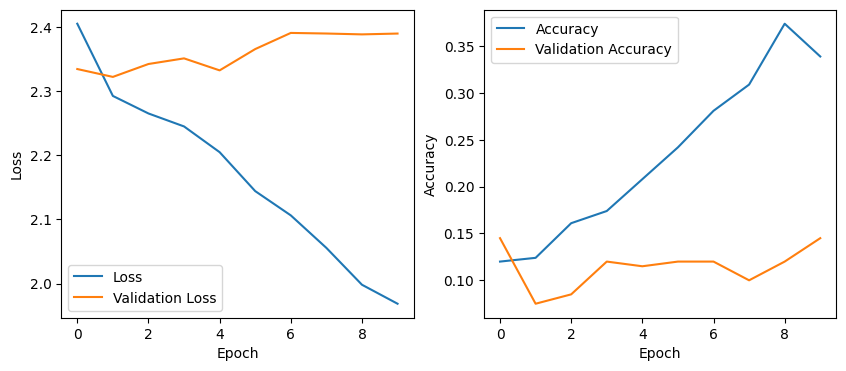

In [32]:
#4. How can you visualize the training progress using TensorFlow and Matplotlib?

import tensorflow as tf
import matplotlib.pyplot as plt

# 1. Define and compile your TensorFlow model (replace with your actual model)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(784,)),
    tf.keras.layers.Dense(10, activation='softmax')
])
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# 2. Create dummy data (REPLACE with your actual data)
import numpy as np
train_data = np.random.rand(1000, 784).astype(np.float32)
train_labels = np.random.randint(0, 10, 1000)
train_labels = tf.keras.utils.to_categorical(train_labels, num_classes=10)
val_data = np.random.rand(200, 784).astype(np.float32)
val_labels = np.random.randint(0, 10, 200)
val_labels = tf.keras.utils.to_categorical(val_labels, num_classes=10)

# 3. Train the model and get the history
history = model.fit(train_data, train_labels, epochs=10, validation_data=(val_data, val_labels), verbose=0)

# 4. Plot the loss and accuracy
plt.figure(figsize=(10, 4))  # Create a figure
plt.subplot(1, 2, 1)        # Create the first subplot (1 row, 2 columns, plot 1)
plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)        # Create the second subplot (1 row, 2 columns, plot 2)
plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()                # Show the plots


In [33]:
#5. How do you install PyTorch and verify the PyTorch installation?
import torch
print(torch.__version__)
print(torch.cuda.is_available())

2.6.0+cu124
False


In [34]:
#6. How do you create a simple neural network in PyTorch?
import torch
import torch.nn as nn
import torch.nn.functional as F

class SimpleNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(SimpleNet, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)  # Hidden layer
        self.fc2 = nn.Linear(hidden_size, output_size) # Output layer

    def forward(self, x):
        x = F.relu(self.fc1(x))  # Apply ReLU activation to the hidden layer output
        x = self.fc2(x)          # Output layer (no activation, for raw scores)
        return x

# Example usage:
input_size = 784    #  for a flattened MNIST image
hidden_size = 128  # Number of neurons in the hidden layer
output_size = 10   # Number of classes (e.g., digits 0-9)

model = SimpleNet(input_size, hidden_size, output_size)
print(model) #prints the model architecture

# Create a dummy input tensor
input_tensor = torch.randn(1, input_size)  # Batch size of 1

# Pass the input through the network
output_tensor = model(input_tensor)
print(output_tensor.shape)  # Prints the shape of the output

SimpleNet(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)
torch.Size([1, 10])


In [36]:
#7. How do you define a loss function and optimizer in PyTorch?
import torch.nn as nn
import torch.optim as optim

# 1. Define the Loss Function
#    --------------------------
#    PyTorch provides various loss functions in the 'torch.nn' module.
#    The choice depends on your task (e.g., classification, regression).

#    Example: Cross-Entropy Loss (for multi-class classification)
criterion = nn.CrossEntropyLoss()

#    Other common loss functions:
#    - nn.MSELoss(): Mean Squared Error (for regression)
#    - nn.BCELoss(): Binary Cross-Entropy Loss (for binary classification)
#    - nn.L1Loss(): L1 Loss (for regression)
#    - nn.CTCLoss(): Connectionist Temporal Classification Loss (for sequence problems)

# 2. Define the Optimizer
#    --------------------------
#    PyTorch provides various optimization algorithms in the 'torch.optim' module.
#    The optimizer updates the model's parameters during training to minimize the loss.

#    Example: Adam optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)  # model.parameters() gives the trainable parameters

#    Common optimizers:
#    - optim.SGD(): Stochastic Gradient Descent
#    - optim.RMSprop(): RMSprop
#    - optim.Adagrad(): Adagrad
#    - optim.Adadelta(): Adadelta

# 3. Inside the Training Loop:
#    --------------------------
#    These steps are performed in each iteration of your training loop:

#    a. Forward Pass:  Calculate the model's output (predictions)
#       output = model(input_data)  # input_data is your input tensor

#    b. Calculate the Loss: Compare the model's output to the true labels.
#       loss = criterion(output, target_labels)  # target_labels is your tensor of correct labels

#    c. Zero the Gradients:  Clear the gradients from the previous iteration.
#       optimizer.zero_grad()

#    d. Backpropagation:  Compute the gradients of the loss with respect to the model's parameters.
#       loss.backward()

#    e. Update Parameters:  Adjust the model's parameters based on the gradients
#       optimizer.step()

# Example (Illustrative):
import torch
import torch.nn as nn
import torch.optim as optim

# Define a simple model (replace with your actual model)
class SimpleNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(SimpleNet, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

input_size = 10
hidden_size = 20
output_size = 5
model = SimpleNet(input_size, hidden_size, output_size)

# Dummy data for demonstration
batch_size = 32
input_data = torch.randn(batch_size, input_size)
target_labels = torch.randint(0, output_size, (batch_size,))  # Example: LongTensor of class indices

# 1. Define Loss Function
criterion = nn.CrossEntropyLoss()

# 2. Define Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.01)

# 3. Training Loop (simplified for demonstration)
num_epochs = 2
for epoch in range(num_epochs):
    # a. Forward pass
    output = model(input_data)

    # b. Calculate loss
    loss = criterion(output, target_labels)

    # c. Zero gradients
    optimizer.zero_grad()

    # d. Backpropagation
    loss.backward()

    # e. Update parameters
    optimizer.step()

    print(f'Epoch {epoch+1}, Loss: {loss.item():.4f}')

Epoch 1, Loss: 1.6127
Epoch 2, Loss: 1.5790


In [37]:
#8. How do you implement a custom loss function in PyTorch?
import torch
import torch.nn as nn
import torch.nn.functional as F

class WeightedCrossEntropyLoss(nn.Module):
    def __init__(self, weights=None):
        super(WeightedCrossEntropyLoss, self).__init__()
        self.weights = weights  # weights should be a 1D tensor, or None

    def forward(self, output, target):
        # output: (batch_size, num_classes) - raw scores (logits)
        # target: (batch_size,) - class indices (LongTensor)

        # Apply the standard cross-entropy loss first
        loss = F.cross_entropy(output, target, reduction='none')  # Get per-sample losses

        # Apply weights if provided
        if self.weights is not None:
            loss = loss * self.weights[target]  # weights[target] gathers weights for each sample's class

        return torch.mean(loss)  # Return the mean loss

# Example usage:
class_weights = torch.tensor([1.0, 1.0, 2.0])  # Example: weight class 2 twice as much
weighted_cross_entropy_loss = WeightedCrossEntropyLoss(weights=class_weights)

# (Inside your training loop...)
# output = model(input_data)
# loss = weighted_cross_entropy_loss(output, target_labels)

In [39]:
#9. How do you save and load a TensorFlow model?
import tensorflow as tf
# Save the model
model_path = 'my_model.h5'  # Or 'my_model' for SavedModel format
simple_model_sequential.save(model_path)  # Saves the model to the specified path

print(f"Model saved to: {model_path}")

Model saved to: my_model.h5
